In [ ]:
"""Determine whether toss winners have statistically higher match win probability."""

In [2]:
# Data Processing & Manipulation
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Data Analysis & Statistics
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, levene, shapiro, zscore
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd


import matplotlib.pyplot as plt
import seaborn as sns

# Visualization - Interactive
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Utilities
import warnings
import os
from pathlib import Path


print(" All libraries imported successfully!")
print(f" Analysis Environment Ready - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

 All libraries imported successfully!
 Analysis Environment Ready - 2026-05-28 02:30:07


In [18]:
ipl_df = pd.read_csv(r"C:\Users\Lenovo\Documents\DE\Week1\DAY 1\stradit-internship\week2\day4\data\ipl.csv")

print("Dataset loaded successfully!")

print(f"\n Dataset Shape: {ipl_df.shape[0]} rows × {ipl_df.shape[1]} columns")
print(f"Memory Usage: {ipl_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print()




print(ipl_df.info())

# create new column id for indexing
ipl_df['id'] = ipl_df.index + 1

print("\nDataset with new 'id' column:")
print(ipl_df.head())


Dataset loaded successfully!

 Dataset Shape: 1169 rows × 19 columns
Memory Usage: 1.25 MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   team1            1169 non-null   object 
 1   team2            1169 non-null   object 
 2   match_date       1169 non-null   object 
 3   toss_winner      1169 non-null   object 
 4   toss_decision    1169 non-null   object 
 5   winner           1146 non-null   object 
 6   player_of_match  1169 non-null   object 
 7   venue            1169 non-null   object 
 8   city             1118 non-null   object 
 9   team1_players    1169 non-null   object 
 10  team2_players    1169 non-null   object 
 11  season           1169 non-null   int64  
 12  match_number     1169 non-null   int64  
 13  match_type       1169 non-null   object 
 14  result           1169 non-null   object 
 15  result_margin 

In [23]:
for i, col in enumerate(ipl_df.columns, 1):
    print(f"{i:2d}. {col}")

print("\n Data Loading Complete.")

 1. team1
 2. team2
 3. match_date
 4. toss_winner
 5. toss_decision
 6. winner
 7. player_of_match
 8. venue
 9. city
10. team1_players
11. team2_players
12. season
13. match_number
14. match_type
15. result
16. result_margin
17. target_runs
18. target_overs
19. super_over
20. id
21. Date

 Data Loading Complete.


In [24]:
# Dataset dimensions
print(f"\nDATASET DIMENSIONS:")
print(f"   • Total Rows: {ipl_df.shape[0]:,}")
print(f"   • Total Columns: {ipl_df.shape[1]}")
print(f"   • Total Cells: {ipl_df.shape[0] * ipl_df.shape[1]:,}")

print()
# Data types overview
print(f"\n DATA TYPES OVERVIEW:")
dtype_counts = ipl_df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   • {dtype}: {count} columns")


DATASET DIMENSIONS:
   • Total Rows: 1,169
   • Total Columns: 21
   • Total Cells: 24,549


 DATA TYPES OVERVIEW:
   • object: 14 columns
   • int64: 3 columns
   • float64: 3 columns
   • datetime64[ns]: 1 columns


In [26]:
# Date range
print(f"\n TEMPORAL COVERAGE:")
ipl_df['Date'] = pd.to_datetime(ipl_df['match_date'], errors='coerce')
print(f"   • Start Date: {ipl_df['Date'].min().strftime('%Y-%m-%d')}")
print(f"   • End Date: {ipl_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"   • Days Covered: {(ipl_df['Date'].max() - ipl_df['Date'].min()).days} days")
print(f"   • Unique Dates: {ipl_df['Date'].nunique()}")


 TEMPORAL COVERAGE:
   • Start Date: 2008-04-18
   • End Date: 2025-06-03
   • Days Covered: 6255 days
   • Unique Dates: 885


In [27]:
print(f"\nNumeric Columns: {ipl_df.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"\nCategorical Columns: {ipl_df.select_dtypes(include=['object']).columns.tolist()}")

print("\n Structure analysis complete!")


Numeric Columns: ['season', 'match_number', 'result_margin', 'target_runs', 'target_overs', 'id']

Categorical Columns: ['team1', 'team2', 'match_date', 'toss_winner', 'toss_decision', 'winner', 'player_of_match', 'venue', 'city', 'team1_players', 'team2_players', 'match_type', 'result', 'super_over']

 Structure analysis complete!


In [45]:
# Calculate missing values
missing_data = pd.DataFrame({
    'Column': ipl_df.columns,
    'Missing_Count': ipl_df.isnull().sum(),
    'Missing_Percentage': (ipl_df.isnull().sum() / len(ipl_df) * 100).round(2),
    'Data_Type': ipl_df.dtypes
})

# Filter columns with missing values
missing_data = missing_data[missing_data['Missing_Count'] > 0]

# Sort by missing percentage
missing_data = missing_data.sort_values(
    by='Missing_Percentage',
    ascending=False
)

print("\nMissing Data Overview:")
print(missing_data.to_string(index=False))

# Overall missing value statistics
total_missing = ipl_df.isnull().sum().sum()
total_cells = ipl_df.shape[0] * ipl_df.shape[1]

print("\nMissing Data Statistics:")
print(f"Total Missing Cells: {total_missing}")
print(f"Total Cells: {total_cells}")
print(f"Missing Percentage: {(total_missing / total_cells) * 100:.2f}%")

# Count columns with missing values
columns_with_missing = ipl_df.isnull().any().sum()
print(f"Columns with Missing Values: {columns_with_missing}")

# Count rows with missing values
rows_with_missing = ipl_df.isnull().any(axis=1).sum()
print(f"Rows with Missing Values: {rows_with_missing}")

# cleanig rows and columns with missing values

ipl_df_cleaned = ipl_df.dropna()
print(f"\nAfter cleaning, dataset shape: {ipl_df_cleaned.shape[0]} rows × {ipl_df_cleaned.shape[1]} columns")

columns_with_missing = ipl_df_cleaned.isnull().any().sum()
print(f"Columns with Missing Values: {columns_with_missing}")

# Count rows with missing values
rows_with_missing = ipl_df_cleaned.isnull().any(axis=1).sum()
print(f"Rows with Missing Values: {rows_with_missing}")

print("\nAnalysis Complete!")


Missing Data Overview:
       Column  Missing_Count  Missing_Percentage Data_Type
         city             51                4.36    object
       winner             23                1.97    object
result_margin             23                1.97   float64
  target_runs              6                0.51   float64
 target_overs              6                0.51   float64

Missing Data Statistics:
Total Missing Cells: 109
Total Cells: 24549
Missing Percentage: 0.44%
Columns with Missing Values: 5
Rows with Missing Values: 73

After cleaning, dataset shape: 1096 rows × 21 columns
Columns with Missing Values: 0
Rows with Missing Values: 0

Analysis Complete!


In [46]:


# Check duplicate rows
duplicate_rows = ipl_df_cleaned.duplicated().sum()
length = len(ipl_df_cleaned)
print(f"Total Rows: {length}")

print("\nDuplicate Rows:")
print(f"Completely Duplicate Rows: {duplicate_rows}")
print(f"Duplicate Percentage: {(duplicate_rows / length) * 100:.2f}%")

# Check duplicate show_id bookings
duplicate_match_ids = ipl_df_cleaned['id'].duplicated().sum()

columns_with_missing = ipl_df_cleaned.isnull().any().sum()
rows_with_missing = ipl_df_cleaned.isnull().any(axis=1).sum()

print("\nMissing Values:")
print(f"Columns with Missing Values: {columns_with_missing}")


print(f"Rows with Missing Values: {rows_with_missing}")


print("\nDuplicate IDs:")
print(f"Duplicate IDs: {duplicate_match_ids}")
print(f"Unique IDs: {ipl_df_cleaned['id'].nunique()}")



print("\nData Quality Assessment:")
total_issues = duplicate_rows + duplicate_match_ids + columns_with_missing + rows_with_missing
print(f"Total Quality Issues Found: {total_issues}")
quality_score = max(0, 100 - ((total_issues / len(ipl_df_cleaned)) * 100))
print(f"Data Quality Score: {quality_score:.2f}%")

# Final conclusion
if total_issues == 0:
    print("Verdict: Excellent - Data is clean and ready for analysis")
else:
    print("Verdict: Some duplicates found - Data cleaning recommended")

print("\nDuplicate analysis complete!")

Total Rows: 1096

Duplicate Rows:
Completely Duplicate Rows: 0
Duplicate Percentage: 0.00%

Missing Values:
Columns with Missing Values: 0
Rows with Missing Values: 0

Duplicate IDs:
Duplicate IDs: 0
Unique IDs: 1096

Data Quality Assessment:
Total Quality Issues Found: 0
Data Quality Score: 100.00%
Verdict: Excellent - Data is clean and ready for analysis

Duplicate analysis complete!


In [58]:
"""Determine whether toss winners have statistically higher match win probability."""

winner_counts = ipl_df_cleaned['winner'].value_counts()
print("\nMatch Winners Distribution:")

print(winner_counts)

toss_counts = ipl_df_cleaned['toss_winner'].value_counts()
print("\nToss Winners Distribution:")
print(toss_counts)




Match Winners Distribution:
winner
Mumbai Indians                 146
Chennai Super Kings            135
Kolkata Knight Riders          132
Rajasthan Royals               111
Royal Challengers Bangalore    108
Sunrisers Hyderabad             85
Kings XI Punjab                 75
Delhi Daredevils                65
Delhi Capitals                  45
Gujarat Titans                  37
Punjab Kings                    34
Lucknow Super Giants            30
Deccan Chargers                 29
Royal Challengers Bengaluru     18
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

Toss Winners Distribution:
toss_winner
Mumbai Indians                 142
Kolkata Knight Riders          125
Chennai Super Kings            121
Rajasthan Royals               117
Royal Challengers Bangalore    101
Sunrisers Hyderabad             82
Delhi Daredevils       

In [59]:

toss_winners = ipl_df_cleaned['toss_winner']
match_winners = ipl_df_cleaned['winner']
toss_win_match_win = (toss_winners == match_winners).sum()
total_matches = len(ipl_df_cleaned)

print(f"\nToss Winners who also won the match: {toss_win_match_win} out of {total_matches} matches")
print(f"Percentage of Toss Winners who won the match: {(toss_win_match_win / total_matches) * 100:.2f}%")

# H0: Toss winners have the same match win probability as toss losers.
# H1: Toss winners have a higher match win probability than toss losers.

# perfrom chi-square test

contingency_table = pd.crosstab(ipl_df_cleaned['toss_winner'], ipl_df_cleaned['winner'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)


print("\nChi-Square Test Results:")
print(f"Chi-Square Statistic: {chi2:.4f}")

print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:")
print(expected)

alpha = 0.05
if p < alpha:
    print("Conclusion: Reject the null hypothesis - Toss winners have a higher match win probability.")
else:
    print("Conclusion: Fail to reject the null hypothesis - No significant difference in match win probability between toss winners and losers.")
    


Toss Winners who also won the match: 570 out of 1096 matches
Percentage of Toss Winners who won the match: 52.01%

Chi-Square Test Results:
Chi-Square Statistic: 5366.1998
P-value: 0.0000
Degrees of Freedom: 324
Expected Frequencies:
[[14.90419708  3.20164234  4.96806569  7.17609489  1.43521898  4.08485401
   8.28010949  0.66240876 14.5729927   3.3120438  16.11861314  1.32481752
   3.75364964 12.25456204  1.1040146   0.5520073  11.92335766  1.98722628
   9.38412409]
 [ 5.29653285  1.13777372  1.76551095  2.55018248  0.5100365   1.45164234
   2.94251825  0.23540146  5.17883212  1.1770073   5.72810219  0.47080292
   1.33394161  4.35492701  0.39233577  0.19616788  4.23722628  0.70620438
   3.33485401]
 [ 6.28193431  1.34945255  2.0939781   3.02463504  0.60492701  1.72171533
   3.4899635   0.27919708  6.14233577  1.3959854   6.79379562  0.55839416
   1.58211679  5.16514599  0.46532847  0.23266423  5.02554745  0.83759124
   3.95529197]
 [ 9.73083942  2.09032847  3.24361314  4.68521898  0.9

VISUALIZATION


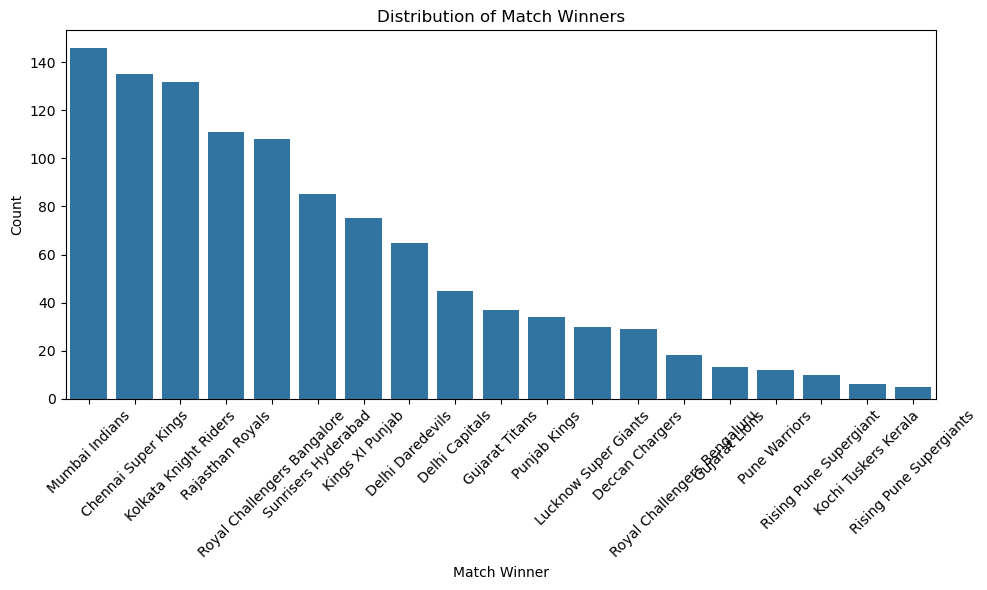

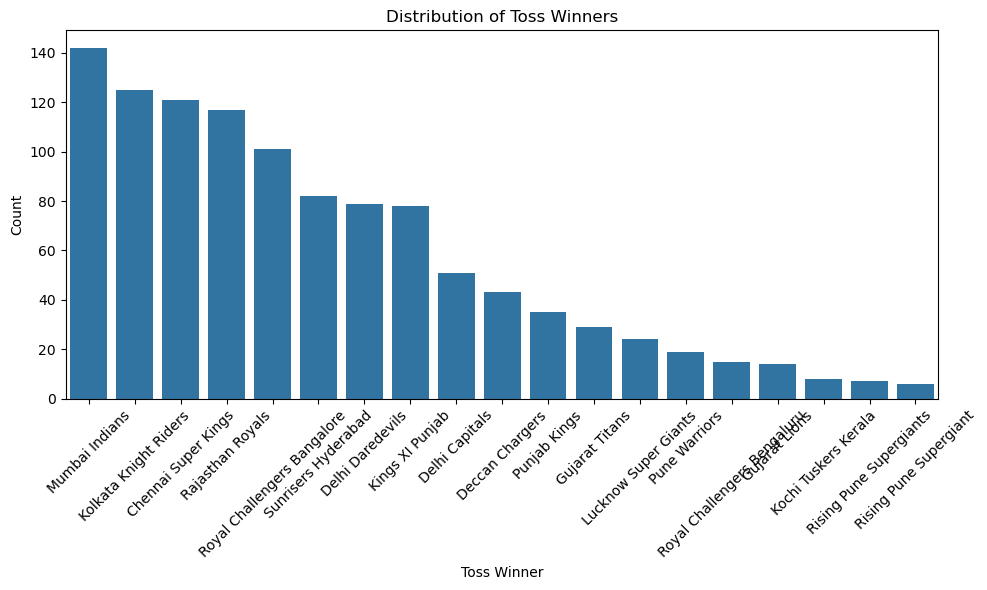

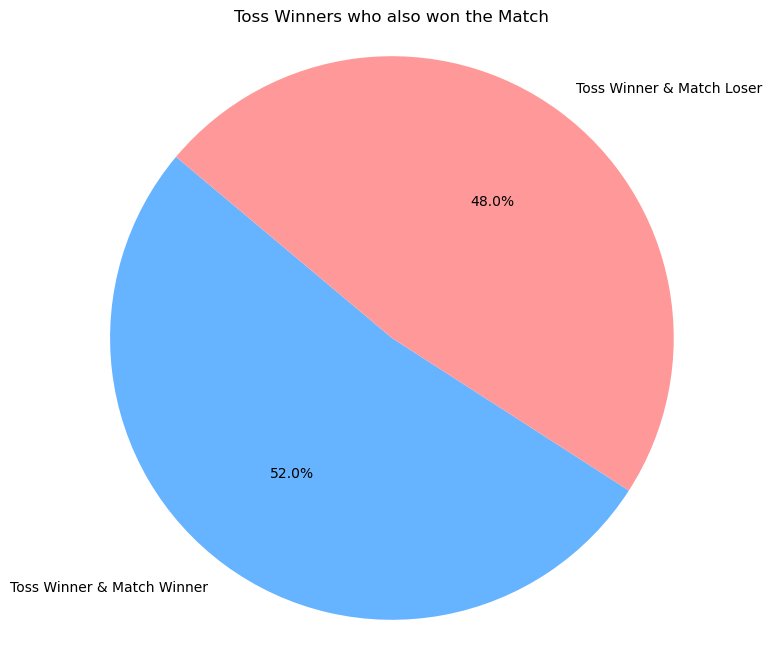

In [69]:
print("VISUALIZATION")


#match winners distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=ipl_df_cleaned, x='winner', order=ipl_df_cleaned['winner'].value_counts().index)
plt.title('Distribution of Match Winners')
plt.xlabel('Match Winner')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# toss winners distribution

plt.figure(figsize=(10, 6))
sns.countplot(data=ipl_df_cleaned, x='toss_winner', order=ipl_df_cleaned['toss_winner'].value_counts().index)
plt.title('Distribution of Toss Winners')
plt.xlabel('Toss Winner')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# pie chart for toss winners who won matches

labels = ['Toss Winner & Match Winner', 'Toss Winner & Match Loser']
sizes = [toss_win_match_win, total_matches - toss_win_match_win]
colors = ['#66b3ff', '#ff9999']
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Toss Winners who also won the Match')
plt.axis('equal')
plt.show()




Team-wise Toss Wins and Match Wins:
                           Team  Toss Wins  Match Wins  Toss Win Percentage  \
10               Mumbai Indians        142         146            12.956204   
0           Chennai Super Kings        121         135            11.040146   
8         Kolkata Knight Riders        125         132            11.405109   
13             Rajasthan Royals        117         111            10.675182   
16  Royal Challengers Bangalore        101         108             9.215328   
18          Sunrisers Hyderabad         82          85             7.481752   
6               Kings XI Punjab         78          75             7.116788   
3              Delhi Daredevils         79          65             7.208029   
2                Delhi Capitals         51          45             4.653285   
5                Gujarat Titans         29          37             2.645985   
12                 Punjab Kings         35          34             3.193431   
9          Luck

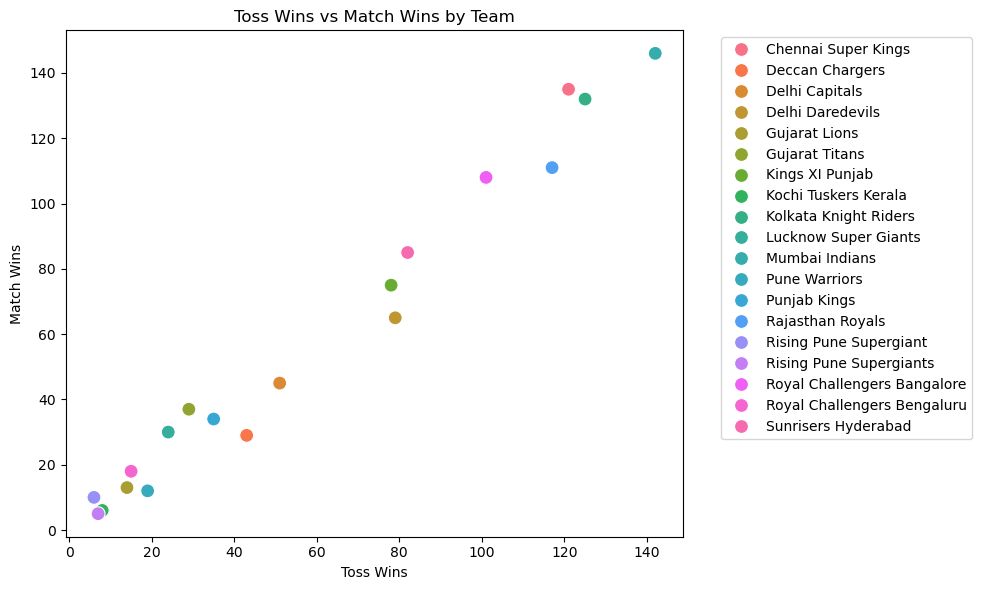

In [74]:
# Analysis of every team's toss wins vs match wins

toss_counts = ipl_df_cleaned['toss_winner'].value_counts()
match_counts = ipl_df_cleaned['winner'].value_counts()  

teams = set(toss_counts.index).union(set(match_counts.index))
toss_wins = [toss_counts.get(team, 0) for team in teams]
match_wins = [match_counts.get(team, 0) for team in teams]
team_stats = pd.DataFrame({
    'Team': sorted(teams),
    'Toss Wins': [toss_counts.get(team, 0) for team in sorted(teams)],
    'Match Wins': [match_counts.get(team, 0) for team in sorted(teams)]

})

team_stats['Toss Win Percentage'] = (team_stats['Toss Wins'] / team_stats['Toss Wins'].sum()) * 100
team_stats['Match Win Percentage'] = (team_stats['Match Wins'] / team_stats['Match Wins'].sum()) * 100
print("\nTeam-wise Toss Wins and Match Wins:")
print(team_stats.sort_values(by='Match Wins', ascending=False))

# Scatter plot of toss wins vs match wins
plt.figure(figsize=(10, 6))
sns.scatterplot(data=team_stats, x='Toss Wins', y='Match Wins', hue='Team', s=100)
plt.title('Toss Wins vs Match Wins by Team')
plt.xlabel('Toss Wins')
plt.ylabel('Match Wins')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



